In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [3]:
df = pd.read_csv("Electric_Production.csv")

values = df["Value"].values.reshape(-1,1)

scaler = MinMaxScaler()
values = scaler.fit_transform(values)

In [4]:
def create_seq(data, seq_len=12):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_seq(values)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [5]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                  torch.tensor(y_train, dtype=torch.float32)),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                  torch.tensor(y_test, dtype=torch.float32)),
    batch_size=32
)

In [6]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(1, 32, batch_first=True)
        self.fc = nn.Linear(32,1)
    def forward(self,x):
        out,_ = self.rnn(x)
        return self.fc(out[:,-1])

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True)
        self.fc = nn.Linear(32,1)
    def forward(self,x):
        out,_ = self.lstm(x)
        return self.fc(out[:,-1])

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(1, 32, batch_first=True)
        self.fc = nn.Linear(32,1)
    def forward(self,x):
        out,_ = self.gru(x)
        return self.fc(out[:,-1])

In [7]:
class SimpleViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(12,64)
        self.fc2 = nn.Linear(64,1)
    def forward(self,x):
        x = x.squeeze(-1)
        x = self.fc1(x)
        return self.fc2(x)

In [8]:
def train_model(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(5):
        total_loss = 0
        for x,y in train_loader:
            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out,y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss/len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    return losses

In [9]:
models = {
    "RNN": RNNModel(),
    "LSTM": LSTMModel(),
    "GRU": GRUModel(),
    "ViT": SimpleViT()
}

results = {}

for name, model in models.items():
    print("\n", name)
    losses = train_model(model)
    results[name] = losses


 RNN
Epoch 1, Loss: 0.0746
Epoch 2, Loss: 0.0359
Epoch 3, Loss: 0.0320
Epoch 4, Loss: 0.0288
Epoch 5, Loss: 0.0267

 LSTM
Epoch 1, Loss: 0.2585
Epoch 2, Loss: 0.1614
Epoch 3, Loss: 0.0799
Epoch 4, Loss: 0.0361
Epoch 5, Loss: 0.0341

 GRU
Epoch 1, Loss: 0.2503
Epoch 2, Loss: 0.1299
Epoch 3, Loss: 0.0532
Epoch 4, Loss: 0.0276
Epoch 5, Loss: 0.0297

 ViT
Epoch 1, Loss: 0.0177
Epoch 2, Loss: 0.0089
Epoch 3, Loss: 0.0066
Epoch 4, Loss: 0.0046
Epoch 5, Loss: 0.0035


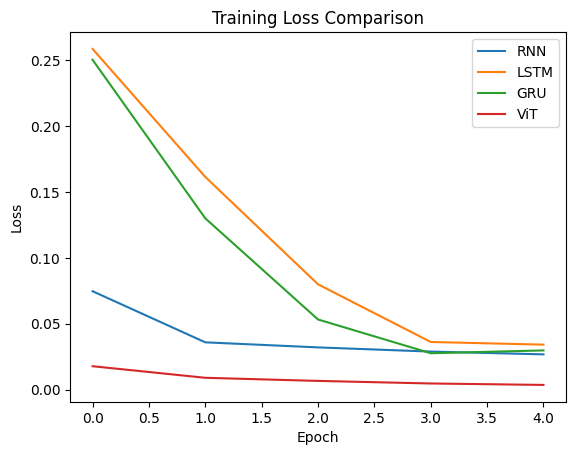

In [10]:
for name, loss in results.items():
    plt.plot(loss, label=name)

plt.legend()
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

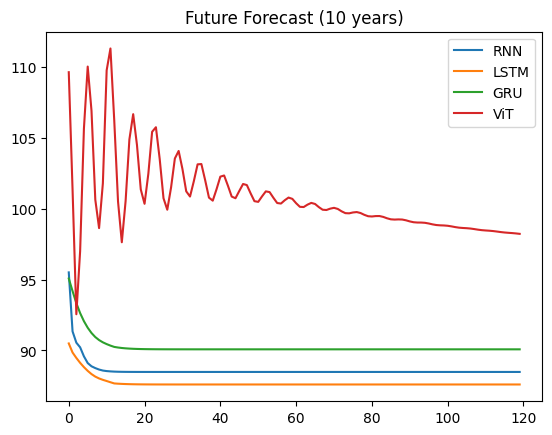

In [11]:
def forecast(model, data, steps=120):
    seq = data[-12:].flatten().tolist()
    preds = []

    for _ in range(steps):
        x = torch.tensor(seq[-12:], dtype=torch.float32).reshape(1,12,1)
        pred = model(x).item()
        preds.append(pred)
        seq.append(pred)

    return scaler.inverse_transform(np.array(preds).reshape(-1,1))

for name, model in models.items():
    future = forecast(model, values)
    plt.plot(future, label=name)

plt.legend()
plt.title("Future Forecast (10 years)")
plt.show()